# Heart Disease Health Risk Prediction System
### Academic Subject: Data Science Using Python
---
**Project Overview:**
This project implements an end-to-end Data Science and Machine Learning workflow to predict cardiovascular disease risk from patient clinical metrics.

**Key Syllabus Topics Covered:**
1. **Data Ingestion & Wrangling:** Pandas DataFrame operations, statistical summaries, data sanity checks.
2. **Exploratory Data Analysis (EDA):** Matplotlib & Seaborn visualizations (Histograms, KDE plots, Correlation Heatmaps, Scatter plots).
3. **Data Preprocessing:** Train-test split with class stratification, feature scaling with `StandardScaler`.
4. **Supervised Classification Algorithms:** Logistic Regression, Decision Trees, Random Forest, and K-Nearest Neighbors.
5. **Model Evaluation:** Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrices.
6. **Model Interpretability:** Feature importance analysis.

## 1. Import Essential Libraries
We import standard Python data science libraries for data manipulation, plotting, and machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
print("All libraries successfully imported!")

All libraries successfully imported!


## 2. Data Ingestion & Overview
We load the standard UCI Cleveland Heart Disease dataset (303 records, 14 medical features).

In [2]:
# Load dataset from data directory
df = pd.read_csv('data/heart_disease.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [3]:
# Schema and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
# Statistical summary of numerical features
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.66,4.72,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.93,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


In [5]:
# Check missing values
print('Total missing values:', df.isnull().sum().sum())

Total missing values: 0


## 3. Exploratory Data Analysis (EDA)
Visualizing target distribution, age trends, correlation heatmap, and clinical relationships.

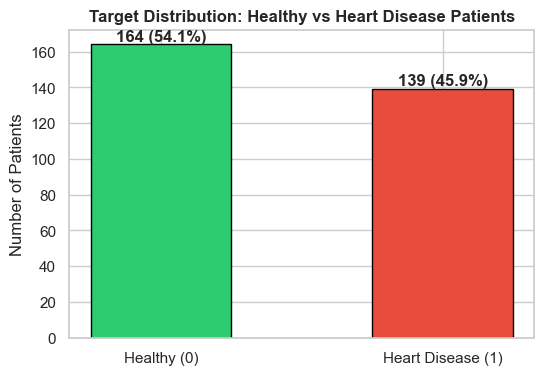

In [6]:
# Target Class Distribution (0 = Healthy, 1 = Heart Disease)
counts = df['target'].value_counts()
plt.figure(figsize=(6, 4))
bars = plt.bar(['Healthy (0)', 'Heart Disease (1)'], [counts[0], counts[1]], color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
plt.title('Target Distribution: Healthy vs Heart Disease Patients', fontsize=12, fontweight='bold')
plt.ylabel('Number of Patients')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 2, f'{h} ({h / len(df) * 100:.1f}%)', ha='center', fontweight='bold')
plt.show()

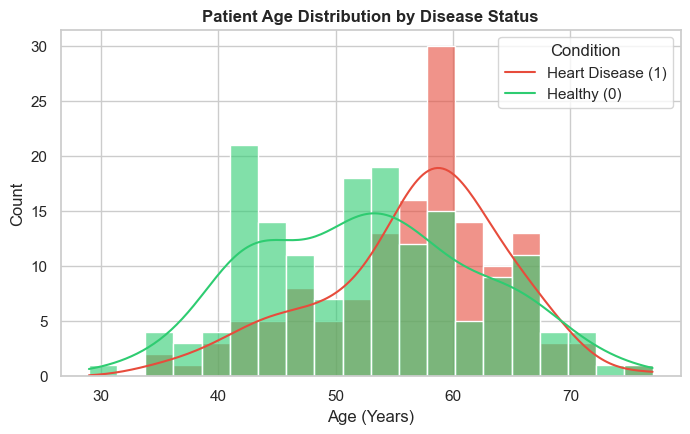

In [7]:
# Age Distribution by Heart Disease Status
plt.figure(figsize=(8, 4.5))
sns.histplot(data=df, x='age', hue='target', kde=True, bins=20, palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.6)
plt.title('Patient Age Distribution by Disease Status', fontsize=12, fontweight='bold')
plt.xlabel('Age (Years)')
plt.legend(labels=['Heart Disease (1)', 'Healthy (0)'], title='Condition')
plt.show()

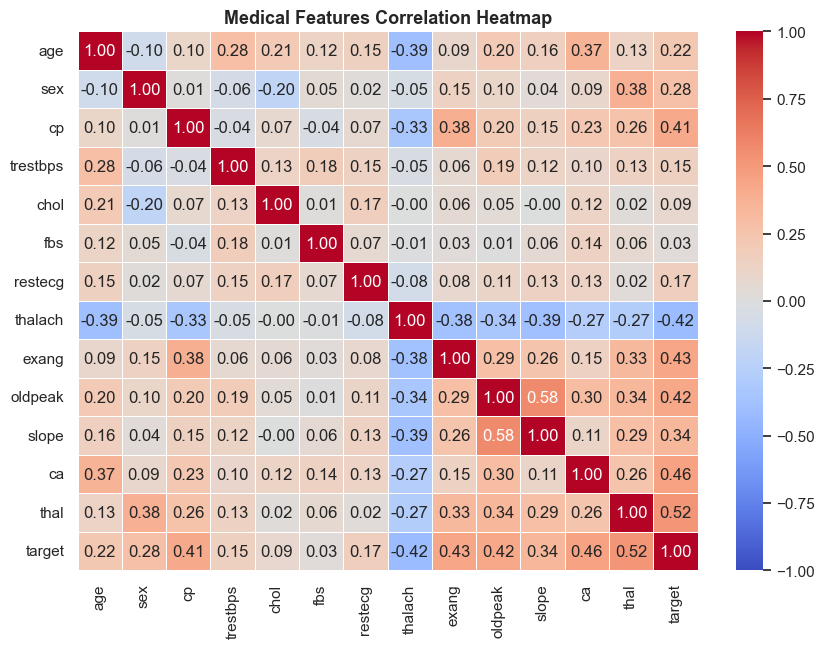

In [8]:
# Feature Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Medical Features Correlation Heatmap', fontsize=13, fontweight='bold')
plt.show()

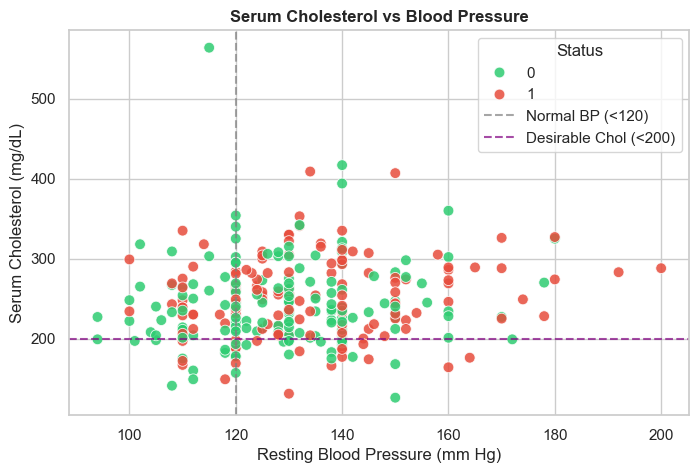

In [9]:
# Serum Cholesterol vs Resting Blood Pressure
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='trestbps', y='chol', hue='target', palette={0: '#2ecc71', 1: '#e74c3c'}, s=60, alpha=0.85)
plt.axvline(120, color='gray', linestyle='--', alpha=0.7, label='Normal BP (<120)')
plt.axhline(200, color='purple', linestyle='--', alpha=0.7, label='Desirable Chol (<200)')
plt.title('Serum Cholesterol vs Blood Pressure', fontsize=12, fontweight='bold')
plt.xlabel('Resting Blood Pressure (mm Hg)')
plt.ylabel('Serum Cholesterol (mg/dL)')
plt.legend(title='Status')
plt.show()

## 4. Data Preprocessing & Stratified Train-Test Split
### Core Syllabus Principles:
- **Train/Test Separation**: 80% train, 20% test.
- **Class Stratification (`stratify=y`)**: Prevents sample skew and ensures the same class proportion across train and test sets.
- **Feature Scaling (`StandardScaler`)**: Crucial for distance-based algorithms like KNN and gradient-based models like Logistic Regression.

In [10]:
X = df.drop('target', axis=1)
y = df['target']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training samples: {len(X_train)} (80%)')
print(f'Testing samples : {len(X_test)} (20%)')

Training samples: 242 (80%)
Testing samples : 61 (20%)


## 5. Machine Learning Model Training & Comparative Benchmark
We benchmark 4 key syllabus classification algorithms:
1. **Logistic Regression**
2. **Decision Tree Classifier**
3. **Random Forest Classifier**
4. **K-Nearest Neighbors (KNN)**

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

results = []
conf_matrices = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    conf_matrices[name] = cm
    
    results.append({
        'Algorithm': name,
        'Accuracy (%)': round(acc * 100, 2),
        'Precision (%)': round(prec * 100, 2),
        'Recall (%)': round(rec * 100, 2),
        'F1-Score (%)': round(f1 * 100, 2),
        'ROC-AUC (%)': round(auc * 100, 2)
    })

results_df = pd.DataFrame(results)
results_df

,Algorithm,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC (%)
0,Logistic Regression,86.89,81.25,92.86,86.67,95.13
1,Decision Tree,78.69,74.19,82.14,77.97,85.98
2,Random Forest,88.52,83.87,92.86,88.14,95.89
3,K-Nearest Neighbors,88.52,80.00,100.00,88.89,92.32


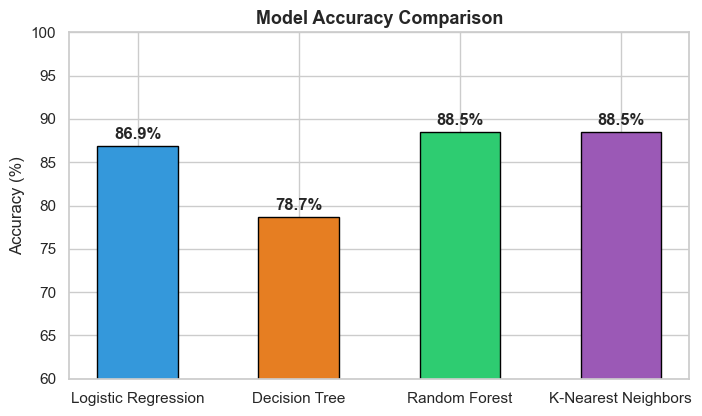

In [12]:
# Accuracy Comparison Bar Plot
plt.figure(figsize=(8, 4.5))
bars = plt.bar(results_df['Algorithm'], results_df['Accuracy (%)'], color=['#3498db', '#e67e22', '#2ecc71', '#9b59b6'], edgecolor='black', width=0.5)
plt.ylim(60, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.8, f'{h:.1f}%', ha='center', fontweight='bold')
plt.show()

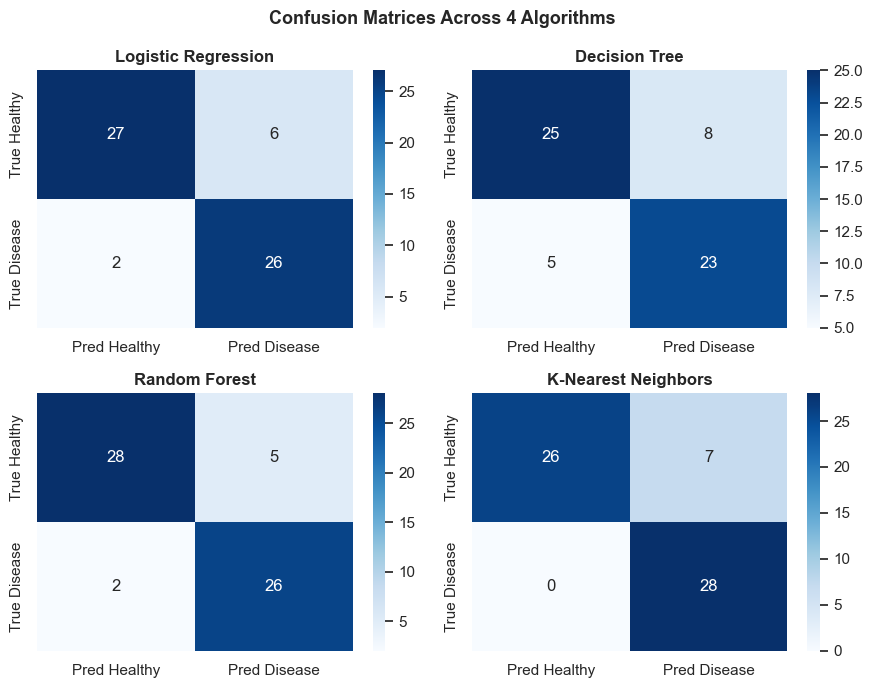

In [13]:
# Confusion Matrix Comparison
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes = axes.flatten()
for idx, (name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Pred Healthy', 'Pred Disease'],
                yticklabels=['True Healthy', 'True Disease'])
    axes[idx].set_title(name, fontweight='bold')
plt.suptitle('Confusion Matrices Across 4 Algorithms', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

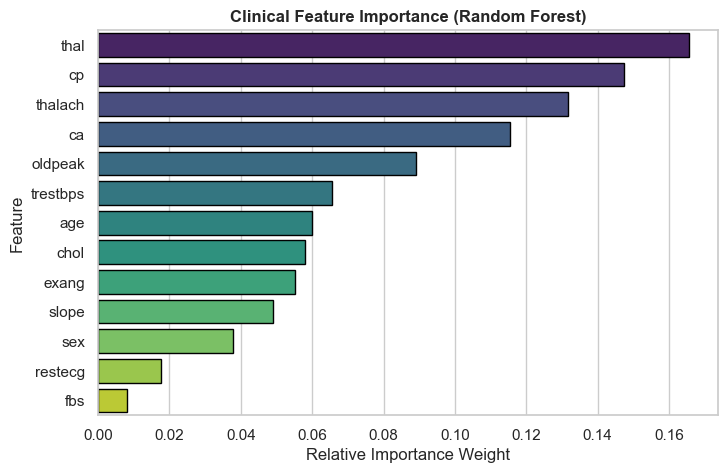

In [14]:
# Feature Importance Analysis (Random Forest)
rf_model = models['Random Forest']
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=fi_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False, edgecolor='black')
plt.title('Clinical Feature Importance (Random Forest)', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance Weight')
plt.show()

## 6. Clinical Inference Demonstration
Testing real patient clinical measurements against our trained model.

In [15]:
demo_model = models['Random Forest']

patient_a = pd.DataFrame([{
    'age': 38, 'sex': 0, 'cp': 2, 'trestbps': 115, 'chol': 180,
    'fbs': 0, 'restecg': 0, 'thalach': 175, 'exang': 0, 'oldpeak': 0.2,
    'slope': 1, 'ca': 0, 'thal': 3
}])

patient_b = pd.DataFrame([{
    'age': 67, 'sex': 1, 'cp': 4, 'trestbps': 160, 'chol': 286,
    'fbs': 0, 'restecg': 2, 'thalach': 108, 'exang': 1, 'oldpeak': 2.6,
    'slope': 2, 'ca': 2, 'thal': 7
}])

for label, p_df in [('Patient A (Healthy Profile)', patient_a), ('Patient B (High-Risk Profile)', patient_b)]:
    p_scaled = scaler.transform(p_df)
    pred = demo_model.predict(p_scaled)[0]
    prob = demo_model.predict_proba(p_scaled)[0][1] * 100
    diagnosis = 'HEART DISEASE DETECTED' if pred == 1 else 'HEALTHY / NEGATIVE'
    print(f'=== {label} ===')
    print(f'  Prediction : {diagnosis}')
    print(f'  Risk Score : {prob:.1f}%\n')

=== Patient A (Healthy Profile) ===
  Prediction : HEALTHY / NEGATIVE
  Risk Score : 2.7%

=== Patient B (High-Risk Profile) ===
  Prediction : HEART DISEASE DETECTED
  Risk Score : 94.7%



## 7. Key Viva Voce Concepts & Academic Summary
1. **Why is Recall more critical than Precision in medical diagnostic models?**
   A False Negative means a sick patient is misclassified as healthy and denied urgent treatment. High recall minimizes false negatives.
2. **Why do we standardize features using `StandardScaler`?**
   Variables with high values (Cholesterol ~250) would disproportionately skew distance/gradient computations over small-scale variables (Oldpeak ~1.0).
3. **What is Data Leakage and how do we prevent it?**
   Data leakage occurs if the test set influences model training. We prevent this by calling `scaler.fit_transform()` on `X_train` only, and `scaler.transform()` on `X_test`.
4. **Why did Random Forest perform best?**
   Random Forest is an ensemble of decorrelated decision trees that reduces variance and captures complex non-linear relationships without overfitting.